In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

In [35]:
file = "/home/zhe2/data/PACE/adding_sif_output/PACE_OCI.20250927T123954.L1B.V3_adding_sif_zeroMagnitude_Rtoa.nc"
ds = xr.open_dataset(file)
ds

<xarray.Dataset> Size: 1MB
Dimensions:             (scans: 51, pixels: 51, state: 15, sif_nev: 1,
                         red_wavelength: 83)
Coordinates:
  * red_wavelength      (red_wavelength) float32 332B 642.0 642.7 ... 754.2
Dimensions without coordinates: scans, pixels, state, sif_nev
Data variables:
    latitude            (scans, pixels) float32 10kB ...
    longitude           (scans, pixels) float32 10kB ...
    x_hat               (state, scans, pixels) float32 156kB ...
    converged           (scans, pixels) uint8 3kB ...
    sif_ev1             (scans, pixels) float32 10kB ...
    sif_coeffs          (sif_nev, scans, pixels) float32 10kB ...
    sif_radiance_678nm  (scans, pixels) float32 10kB ...
    sif_added_678nm     (scans, pixels) float32 10kB ...
    rmse                (red_wavelength, scans, pixels) float32 864kB ...
Attributes:
    title:            PACE AddingSIF retrieval output (spectrally resolved rmse)
    history:          Created 2026-03-19T23:27:58
    input_pace_file:  /home/zhe2/data/PACE/adding_sif_interim/interim_2025092...
    config_file:      /home/zhe2/data/PACE/adding_sif_interim/merged_config_a...
    state_names_csv:  vcd_o2_intercept,vcd_o2_slope,vcd_h2o_intercept,vcd_h2o...
    pixel_start:      1100
    pixel_end:        1150
    scan_start:       300
    scan_end:         350

In [36]:
# wavelength
wavelength = ds["red_wavelength"]
# rmse
rmse = ds["rmse"]
# converged
converged = ds["converged"]
# select ONLY the converged pixels
rmse_conv = np.where(converged==1, rmse, np.nan)
# squeeze the first two dimensions
rmse_flat = rmse.values.reshape(rmse_conv.shape[0], rmse_conv.shape[1]*rmse_conv.shape[2])
rmse_conv_flat = rmse_conv.reshape(rmse_conv.shape[0], rmse_conv.shape[1]*rmse_conv.shape[2])
print(np.nansum(rmse_conv_flat==rmse_conv_flat))
print(np.nansum(rmse_flat==rmse_flat))

6806
200528


/home/zhe2/anaconda3/envs/pace/lib/python3.13/site-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
/home/zhe2/anaconda3/envs/pace/lib/python3.13/site-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
/home/zhe2/anaconda3/envs/pace/lib/python3.13/site-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


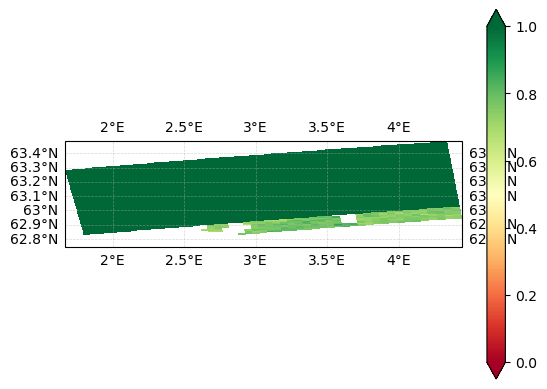

In [39]:
lat = ds["latitude"]
lon = ds["longitude"]
converged = ds["converged"]
sif_radiance_678nm = ds["sif_radiance_678nm"]
sif_radiance_678nm_conv = np.where(converged==1, sif_radiance_678nm, np.nan)

# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

# Set global extent
buffer_bnd = .25
lon_min = np.min(lon) - buffer_bnd
lon_max = np.max(lon) + buffer_bnd
lat_min = np.min(lat) - buffer_bnd
lat_max = np.max(lat) + buffer_bnd
extend = [lon_min, lon_max, lat_min, lat_max]
# ax.set_extent(extend, crs=ccrs.PlateCarree()) 

# Plot nFLH data using contourf
im = ax.pcolormesh(lon, lat, sif_radiance_678nm, 
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 vmin = 0.,
                 vmax = 1.,
                #  levels=np.linspace(0, 1.4009, 20)
                 )
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

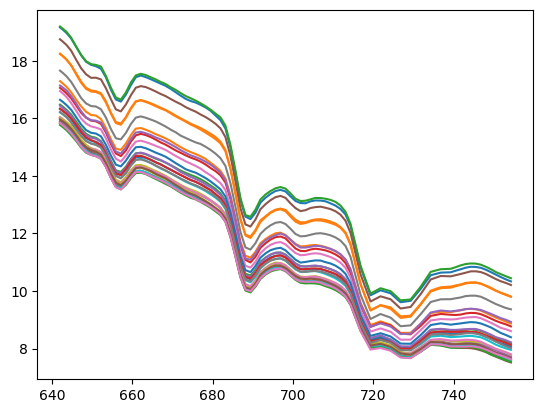

In [30]:
Rtoa_red = ds["Rtoa_red"]
red_wavelength = ds["red_wavelength"]
R_toa_red = Rtoa_red.values.reshape(Rtoa_red.shape[0], Rtoa_red.shape[1]*Rtoa_red.shape[2])

idx = np.where(R_toa_red[0,:]>=-np.inf)[0]

plt.plot(red_wavelength, R_toa_red[:,idx[::60]])

In [31]:
# load L2 AOP and BGC data - nflh and chlor_a
granule_id = '20250927T123954'
dir_aop = "/home/zhe2/data/PACE/L2_AOP_V3.1/"
dir_bgc = "/home/zhe2/data/PACE/L2_BGC_V3.1/"
file_aop = dir_aop + "PACE_OCI." + granule_id + ".L2.OC_AOP.V3_1.nc"
file_bgc = dir_bgc + "PACE_OCI." + granule_id + ".L2.OC_BGC.V3_1.nc"
dtr_aop = xr.open_datatree(file_aop)
ds_aop = xr.merge(dtr_aop.to_dict().values())
dtr_bgc = xr.open_datatree(file_bgc)
ds_bgc = xr.merge(dtr_bgc.to_dict().values())

# lat and lon
lat_l2 = ds_bgc['latitude'].values
lon_l2 = ds_bgc['longitude'].values
# chlor_a
chlor_a = ds_bgc['chlor_a'].values
# nflh
nflh = ds_aop['nflh'].values
# phytoplankton carbon
phyto_c = ds_bgc['carbon_phyto'].values
# poc
poc = ds_bgc['poc'].values

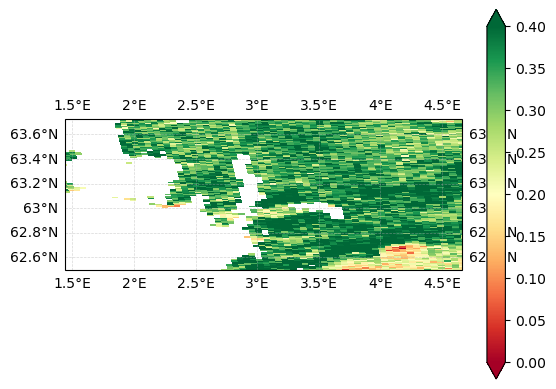

In [32]:
# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

ax.set_extent(extend, crs=ccrs.PlateCarree()) 

# Plot nFLH data using contourf
im = ax.pcolormesh(lon_l2, lat_l2, nflh, 
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 vmin = 0.,
                 vmax = 0.4,
                #  levels = np.linspace(0, 1.4009, 20)
                 )
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

In [33]:
# check another batch retrieval file
file1 = "/home/zhe2/data/PACE/xSec_fit_output/interim_20250927T123954_retrieval_full_parallel.nc"
ds1 = xr.open_dataset(file1)
# loc
lat_ds1 = ds1['latitude'].values
lon_ds1 = ds1['longitude'].values
# sif 678 nm
sif_678_ds1 = ds1['sif_radiance_678nm'].values


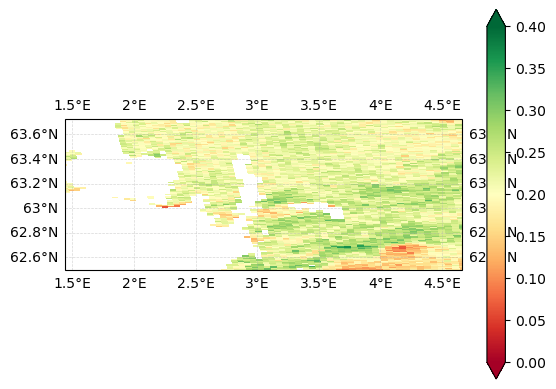

In [34]:
# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

ax.set_extent(extend, crs=ccrs.PlateCarree()) 

# Plot nFLH data using contourf
im = ax.pcolormesh(lon_ds1, lat_ds1, sif_678_ds1, 
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 vmin = 0.,
                 vmax = 0.4,
                #  levels = np.linspace(0, 1.4009, 20)
                 )
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')